[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


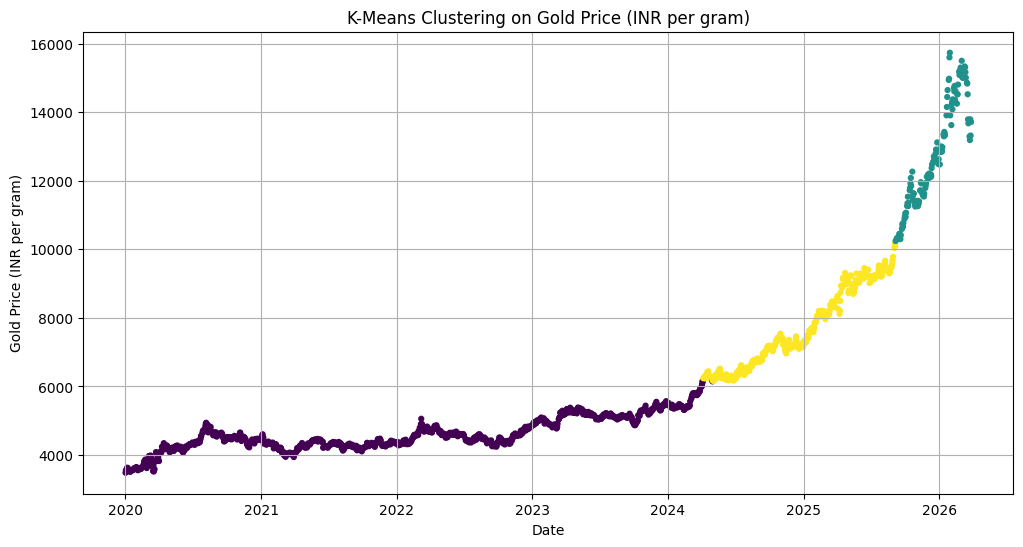

K-Means Cluster Centers (INR per gram):
Cluster 0: 4610.74
Cluster 1: 12723.48
Cluster 2: 7689.69


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import yfinance as yf

gold = yf.download("GC=F", start="2020-01-01")
fx = yf.download("USDINR=X", start="2020-01-01")

gold.columns = gold.columns.get_level_values(0)
fx.columns = fx.columns.get_level_values(0)

gold = gold[['Close']].rename(columns={'Close': 'Gold_USD'}).dropna()
fx = fx[['Close']].rename(columns={'Close': 'USDINR'}).dropna()

df = gold.join(fx, how='inner')
df['Gold_INR'] = df['Gold_USD'] * df['USDINR']
df['Gold_INR_per_gram'] = df['Gold_INR'] / 31.1034768

X = df[['Gold_INR_per_gram']]

#clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

# Plot
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Gold_INR_per_gram'], 
            c=df['KMeans_Cluster'], cmap='viridis', s=12)

plt.title("K-Means Clustering on Gold Price (INR per gram)")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per gram)")
plt.grid(True)
plt.show()

print("K-Means Cluster Centers (INR per gram):")
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: {center[0]:.2f}")